# Quantifying structure across brain regions

The main question se are interested here is

**Is there geometrical structure shared across different brain regions?**

We'll answer this with the International Brain Laboratory brain-wide map: mice performing a decision-making task, recorded across many cortical regions. Here the different **systems** to compare are the **brain regions** themselves.

Following the shape-metrics recipe, we will need to:

1. **Construct** a representation matrix for each region (neurons x task features);
2. **Compare** matrices pairwise with the Procrustes distance;
3. **Analyse** the resulting distance matrix: does it relate to anything we already know about these regions, like their anatomical connectivity or their position in the cortical hierarchy?


## 1. Loading the data and building the representation matrices

A representation matrix is *conditions x neurons*: each column is one
neuron's tuning to a set of task conditions. Comparing regions means
comparing these matrices.

All data is open access from ONE-api, under the tag `brainwidemap`; see the [IBL docs](
https://docs.internationalbrainlab.org/notebooks_external/data_download.html)
for how to search and download sessions and raw spike data. 

Here we start from an already-fit encoding model, so loading is a couple of lines.


### The Posani, Wang et al. (2026) RRR encoding model

The conditions for the representation matrices could be anything you consider important for highlighting task and region modulation. **One possibility** could be the spike counts across different windows under each contrast, for the IBL task.

However, rather than a raw spike count, we are using the encoding model from [Posani et al (2026)](https://www.nature.com/articles/s41586-026-10668-4) and representing each neuron by its time-varying coefficients from a reduced-rank regression fit against 8 task and behavioral variables (block, stimulus side, contrast, choice, outcome, wheel, whisking, licking). 

These coefficients are the "conditions" our
representation matrices are built from.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import data
import utils

d = data.Dataset()
print(d)
print(", ".join(f"{a}({n})" for a, n in zip(d.regions, d.counts)))


Dataset(4617 selective neurons, 22 regions)
VISp(160), AUDp(164), SSp-ll(74), SSp-n(191), SSp-ul(100), SSp-m(465), SSp-bfd(185), SSs(269), SSp-tr(92), MOp(754), RSPv(87), RSPd(68), GU(76), ORBl(67), AId(144), VISpm(77), PL(103), VISa(316), VISam(76), MOs(383), ORBvl(121), ACAd(120)


`d.features()` gives, per neuron, its coefficients from the encoding model. In `"temporal"` mode (the default) a row has shape `8 variables x 100 time bins`, flattened to 800 features, which is one neuron's full tuning profile.


(n_neurons, n_features): (4617, 800)
region of neuron 0: RSPv


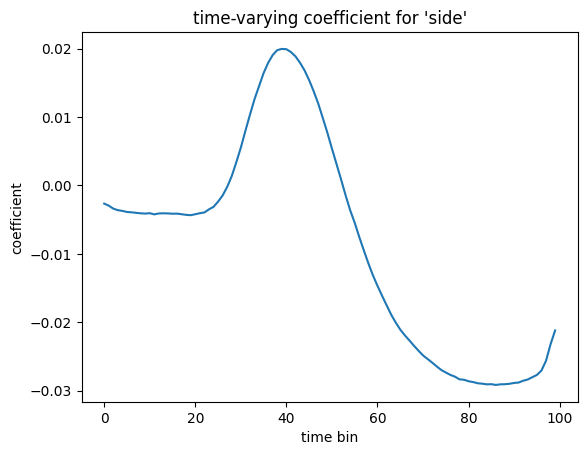

In [2]:
# Example
print("(n_neurons, n_features):", d.features().shape)
print("region of neuron 0:", d.acronym[0])

plt.plot(d.features()[0, 100:200])
plt.title(f"time-varying coefficient for '{data.VAR_LIST[1]}'")
plt.xlabel("time bin")
plt.ylabel("coefficient")
plt.show()


To compare regions rather than neurons, we stack the neurons of one region
into a single matrix $X_\text{region} \in \mathbb{R}^{N_\text{region} \times 800}$:


In [3]:
region = d.regions[0] # example region
X_region = d.features()[d.neurons(region)]
print(f"representation of {region}: {X_region.shape}")


representation of VISp: (160, 800)


Now, we can compute the Procrurstes distance **between** regions `X` and `Y` as:

$$d(X, Y) = \min_{Q\ \mathrm{orthogonal}} \lVert X - YQ \rVert_F$$
 
For computing the distance, we need first to solve for `Q`. How?

_________________________________________________________________________

Lets recall that the [Frobenius norm](https://en.wikipedia.org/wiki/Matrix_norm#Frobenius_norm) can be written as an [inner product](https://en.wikipedia.org/wiki/Inner_product_space):

$$
\|X-YQ\|_F^2
=
\langle X-YQ,X-YQ\rangle_F,
$$

where (remember: the [trace (Tr)](https://en.wikipedia.org/wiki/Trace_(linear_algebra)) is the sum of the main diagonal)

$$
\langle A,B\rangle_F
=
\operatorname{Tr}(A^TB).
$$

Expanding the inner product gives

$$
\begin{aligned}
\|X-YQ\|_F^2
&=
\|X\|_F^2
+
\|YQ\|_F^2
-
2\langle X,YQ\rangle_F.
\end{aligned}
$$

Because `Q` is orthogonal, 

$$
\|YQ\|_F^2
=
\operatorname{Tr}(Q^TY^TYQ)
=
\operatorname{Tr}(Y^TY)
=
\|Y\|_F^2.
$$

Thus,

$$
\boxed{
\|X-YQ\|_F^2
=
\|X\|_F^2+\|Y\|_F^2
-
2\langle X,YQ\rangle_F
}
$$

Since the first two terms are independent of `Q`, minimizing the Procrustes objective is equivalent to

$$
\boxed{
\max_{Q\ \mathrm{orthogonal}}
\langle X,YQ\rangle_F
}
$$


Using the definition of the Frobenius inner product,

$$
\langle X,YQ\rangle_F
=
\operatorname{Tr}(X^TYQ).
$$

Now compute the SVD of $X^TY=U\Sigma V^T$, where $U$ and $V$ are orthogonal and $\Sigma$ is diagonal. Substituting the SVD,

$$
\begin{aligned}
\operatorname{Tr}(X^TYQ)
&=
\operatorname{Tr}(U\Sigma V^TQ)\\
&=
\operatorname{Tr}(\Sigma V^TQU).
\end{aligned}
$$

Since `V`, `Q`, and `U` are orthogonal, $S=V^TQU$ is also orthogonal:

Therefore, our optimization problem becomes

$$
\max_{S\ \mathrm{orthogonal}}
\operatorname{Tr}(\Sigma S).
$$

Since S is orthogonal, all its diagonal elements are $\leq$ 1. Therefore, given that $\Sigma$ is diagonal, this expression is maximized when $S=I$. Thus

$$
\boxed{Q^*=VU^T}.
$$
 


In [ ]:
### Exercise: fill the procristes distance computation
def center(X):
    return X - X.mean(axis=0, keepdims=True)


def procrustes_distance(X, Y):
    X, Y = center(X), center(Y)

    d2 = ... # Norm of X + Norm of Y - Tr(SVD(X^TY))

    return np.sqrt(max(d2, 0.0))


In [ ]:
def center(X):
    return X - X.mean(axis=0, keepdims=True)

def procrustes_distance(X, Y):
    X, Y = center(X), center(Y)
    s = np.linalg.svd(X.T @ Y, compute_uv=False).sum()
    d2 = (X ** 2).sum() + (Y ** 2).sum() - 2 * s
    return np.sqrt(max(d2, 0.0))


## 2. Computing and visualizing the distance matrix

To compare more than two regions we need to compute the distance between every pair of regions.

To avoid noise and create a distribution of distances between regions, we can at each time subsample n=50 neurons from a region and compute the distances on each subsample fold.

In [5]:
### Exercise: compute pairwise distances across regions
def pairwise(Xs):
    """D[i, j] = procrustes_distance(Xs[i], Xs[j]) for a list of K matrices."""
    D = ...
    return D


def distance_matrix(data, mode="temporal", n_pcs=25, n_sub=50, n_repeats=20, seed=0):
    """K x K matrix of Procrustes distances between the regions of `data`.

    Every region is subsampled to `n_sub` neurons so that region size cannot drive
    the distances, and the matrix is averaged over `n_repeats` subsamples.
    """
    rng = np.random.default_rng(seed)
    features = data.features(mode)
    idx = {a: data.neurons(a) for a in data.regions}
    D = np.zeros((len(data.regions), len(data.regions)))
    for _ in range(n_repeats):
        Xs = [utils.preprocess(features[rng.choice(idx[a], n_sub, replace=False)].T, n_pcs)
              for a in data.regions]
        D += pairwise(Xs)
    return D / n_repeats


In [5]:
def pairwise(Xs):
    """D[i, j] = procrustes_distance(Xs[i], Xs[j]) for a list of K matrices."""
    K = len(Xs)
    D = np.zeros((K, K))
    for i in range(K):
        for j in range(i + 1, K):
            D[i, j] = D[j, i] = procrustes_distance(Xs[i], Xs[j])
    return D


def distance_matrix(data, mode="temporal", n_pcs=25, n_sub=50, n_repeats=20, seed=0):
    """K x K matrix of Procrustes distances between the regions of `data`.

    Every region is subsampled to `n_sub` neurons so that region size cannot drive
    the distances, and the matrix is averaged over `n_repeats` subsamples.
    """
    rng = np.random.default_rng(seed)
    features = data.features(mode)
    idx = {a: data.neurons(a) for a in data.regions}
    D = np.zeros((len(data.regions), len(data.regions)))
    for _ in range(n_repeats):
        Xs = [utils.preprocess(features[rng.choice(idx[a], n_sub, replace=False)].T, n_pcs)
              for a in data.regions]
        D += pairwise(Xs)
    return D / n_repeats

In [6]:
# Compute distance matrix and order 
D = distance_matrix(d, n_pcs=25, n_sub=50, n_repeats=20)

print(f"Mean distance across regions: {D[np.triu_indices(len(D), 1)].mean():.3f}")


Mean distance across regions: 0.711


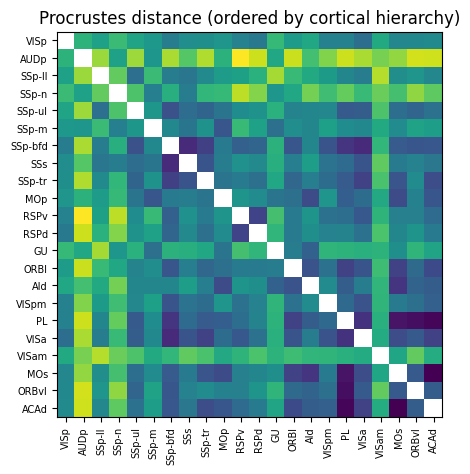

In [8]:
def plot_distance_matrix(D, data, ax=None):
    ax = ax or plt.subplots(figsize=(5, 5))[1]
    order = np.argsort(data.hierarchy())

    M = D[order][:, order].copy()
    np.fill_diagonal(M, np.nan)

    ax.imshow(M)
    ax.set_xticks(range(len(D)), data.regions[order], rotation=90, fontsize=7)
    ax.set_yticks(range(len(D)), data.regions[order], fontsize=7)
    ax.set_title("Procrustes distance (ordered by cortical hierarchy)")

    return ax

plot_distance_matrix(D, d)
plt.show()


## 3. Analysis

One first question we can ask is:

**Does the distance tracks anatomical connectivity?**

To test it quantitatively, we correlate each pair's Procrustes distance against the anatomical connectivity between the same two regions, from Harris et al. (2019).


In [9]:
def pairs(M):
    """Upper-triangular entries of a square matrix, as a flat vector"""
    return M[np.triu_indices(len(M), 1)]

dist = pairs(D)
conn = pairs(d.connectivity())

rho, p = spearmanr(dist, conn)
fit = LinearRegression().fit(dist.reshape(-1, 1), conn)
r2 = r2_score(conn, fit.predict(dist.reshape(-1, 1)))

print(f"spearman(distance, connectivity) = {rho:.2f}, p = {p:.1e}")
print(f"in-sample R2 of the linear fit = {r2:.3f}")


spearman(distance, connectivity) = -0.51, p = 2.2e-16
in-sample R2 of the linear fit = 0.232


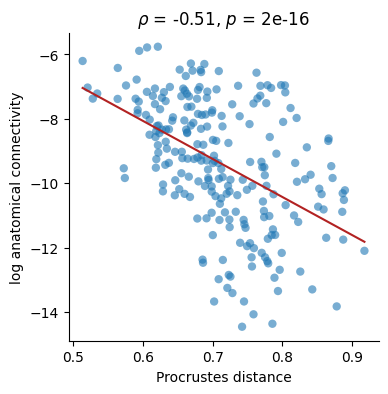

In [11]:
def plot_fit(x, y, model, xlabel, ylabel, title=None, ax=None):
    ax = ax or plt.subplots(figsize=(4, 4))[1]
    ax.scatter(x, y, alpha=0.6, edgecolor="none")
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    ax.plot(x_line, model.predict(x_line), color="firebrick")
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title)
    utils.clean_axes(ax)
    return ax

plot_fit(dist, conn, fit, "Procrustes distance", "log anatomical connectivity",
         title=f"$\\rho$ = {rho:.2f}, $p$ = {p:.0e}")
plt.show()


We can see that distance and connectivity are correlated: regions that are more strongly connected tend to sit closer together in representational geometry. 

Another question we can ask is:

**Does region geometry also track the cortical hierarchy?**

To do that, we can check if, based on the distance matrix, we can predict the position on the hierarchy. To get euclidean features from the distance matrix, we can compute the closed-form multidimensional scaling to obtain euclidean representations of each region.


In [10]:
def classical_mds(D, n_components=2):
    """Classical/metric MDS: eigendecomposition of the double-centered -D^2/2."""
    n = len(D)
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    eigval, eigvec = np.linalg.eigh(B)
    order = np.argsort(eigval)[::-1][:n_components]
    return eigvec[:, order] * np.sqrt(np.clip(eigval[order], 0, None))

xy = classical_mds(D, n_components=2)


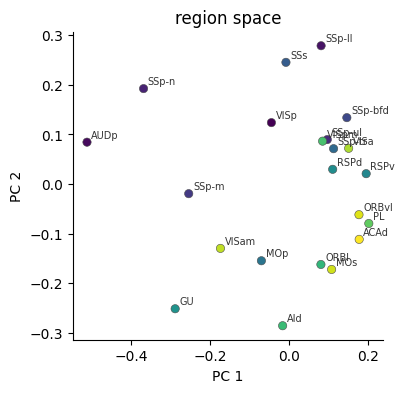

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))

# the embedding itself, colored by hierarchy
colors = utils.hierarchy_colors(d)
ax.scatter(xy[:,0], xy[:,1], c=colors, edgecolor="0.3", linewidth=0.4)
utils.label_points(ax, *xy.T, d.regions)
ax.set(xlabel="PC 1", ylabel="PC 2", title="region space")
utils.clean_axes(ax)


To test whether this space predicts the hierarchy, we use **leave-one-region-out**
regression: each region's hierarchy position is predicted from a model fit on
every *other* region, so a region's own distances never help predict it.


In [ ]:
# Exercise
def leave_one_out_regression(X, y):
    """Predict each y[k] from a linear model fit on every point but k.

    Returns the held-out predictions, their R2 against y, and their rank
    correlation with y.
    """
    X = np.atleast_2d(X)

    pred = ...
    # Compute leave-one-region-out regression to predict cortical hierarchy


    ######

    r2 = r2_score(y, pred)
    rho = spearmanr(y, pred)[0]
    return pred, r2, rho

hierarchy = d.hierarchy()
pred_hierarchy, r2_hier, rho_hier = leave_one_out_regression(xy, hierarchy)
print(f"leave-one-region-out: R2 = {r2_hier:.3f}, rho = {rho_hier:+.2f}")


leave-one-region-out: R2 = 0.495, rho = +0.74


In [12]:
def leave_one_out_regression(X, y):
    """Predict each y[k] from a linear model fit on every point but k.

    Returns the held-out predictions, their R2 against y, and their rank
    correlation with y.
    """
    X = np.atleast_2d(X)
    pred = np.empty(len(y))
    for k in range(len(y)):
        train = np.arange(len(y)) != k
        model = LinearRegression().fit(X[train], y[train])
        pred[k] = model.predict(X[k:k + 1])[0]
    r2 = r2_score(y, pred)
    rho = spearmanr(y, pred)[0]
    return pred, r2, rho

xy = classical_mds(D, n_components=25)

hierarchy = d.hierarchy()
pred_hierarchy, r2_hier, rho_hier = leave_one_out_regression(xy, hierarchy)
print(f"leave-one-region-out: R2 = {r2_hier:.3f}, rho = {rho_hier:+.2f}")


leave-one-region-out: R2 = 0.395, rho = +0.61


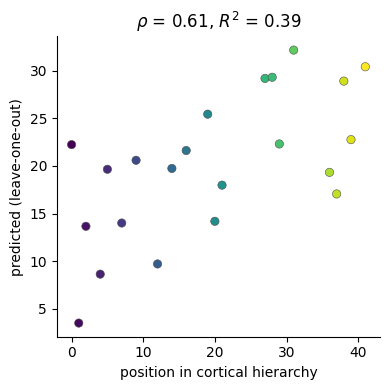

In [13]:
fig, ax = plt.subplots( figsize=(4, 4))

# what that space predicts
ax.scatter(hierarchy, pred_hierarchy, c=colors, edgecolor="0.3", linewidth=0.4)
ax.set(xlabel="position in cortical hierarchy", ylabel="predicted (leave-one-out)",
            title=f"$\\rho$ = {rho_hier:.2f}, $R^2$ = {r2_hier:.2f}")
utils.clean_axes(ax)

plt.tight_layout()
plt.show()


Region geometry alone, with no anatomical information at all, predicts where a region sits in the cortical hierarchy. Together, this suggests the same representational geometry that distinguishes regions also tracks known anatomical organisation.
